In [1]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from src.evaluation import evaluate_thresholds
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/test_scored.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,Amount_log,Hour,iso_score,lof_score
0,-0.026360,0.579105,0.376950,-0.442899,0.464463,0.274140,-0.730652,0.309976,-0.578496,-0.064680,...,0.929646,0.799091,-0.219985,0.156875,-0.296389,0,-1.038714,0.777778,0.053220,9.095938e-12
1,-0.400865,-0.366611,0.801865,0.378314,0.450650,0.210338,-0.039301,0.404799,0.219996,-0.571870,...,-0.395165,-0.575709,-2.467314,-0.947618,-0.248666,0,-0.602448,-0.111111,0.023609,9.027303e-12
2,-0.347195,-0.184225,-0.220755,0.492012,-0.808249,-0.450419,0.241960,-0.661986,-0.091037,-2.080851,...,-0.489832,0.108854,1.010436,1.744868,-0.097680,0,-0.146665,0.000000,0.114474,3.135449e-11
3,0.374283,-0.036171,0.716089,-0.610591,-0.004413,0.177517,-0.921952,0.654798,0.211733,-0.078890,...,-0.534915,-0.170479,-0.153585,0.238130,0.488400,0,0.373809,-0.777778,0.031302,1.200725e-11
4,0.067384,0.818036,0.221639,0.046265,2.443873,0.109579,1.066747,-0.680389,0.400574,0.593964,...,-0.335447,0.056953,-0.129906,-0.411242,-0.306995,0,-1.267180,-1.555556,0.219290,7.274336e-12


In [3]:
print(df['Class'].value_counts())


Class
0    56863
1      492
Name: count, dtype: int64


In [5]:
iso_results = evaluate_thresholds(df, score_col='iso_score')
lof_results = evaluate_thresholds(df, score_col='lof_score')

In [6]:
iso_best = iso_results.sort_values('f1', ascending=False).iloc[0]
lof_best = lof_results.sort_values('f1', ascending=False).iloc[0]

print("ISO BEST:\n", iso_best)
print("\nLOF BEST:\n", lof_best)

ISO BEST:
 threshold    0.489796
precision    0.347477
recall       0.615854
f1           0.444282
Name: 24, dtype: float64

LOF BEST:
 threshold    0.000000
precision    0.008578
recall       1.000000
f1           0.017011
Name: 0, dtype: float64


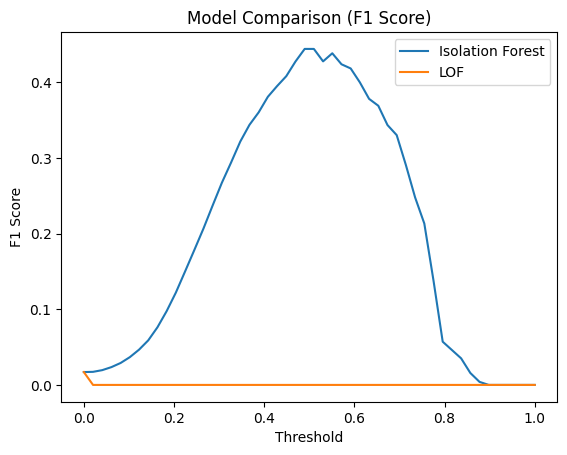

In [8]:
plt.plot(iso_results['threshold'], iso_results['f1'], label='Isolation Forest')
plt.plot(lof_results['threshold'], lof_results['f1'], label='LOF')

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Model Comparison (F1 Score)")

plt.legend()
plt.show()

In [10]:
import pandas as pd

df = pd.read_csv("../data/test_scored.csv")

# Define thresholds (based on your analysis)
LOW_RISK = 0.3
MEDIUM_RISK = 0.5
HIGH_RISK = 0.7

def assign_risk(score):
    if score < LOW_RISK:
        return "LOW"
    elif score < MEDIUM_RISK:
        return "MEDIUM"
    elif score < HIGH_RISK:
        return "HIGH"
    else:
        return "CRITICAL"

df['risk_bucket'] = df['iso_score'].apply(assign_risk)

df[['iso_score', 'risk_bucket']].head()

,iso_score,risk_bucket
0,0.053220,LOW
1,0.023609,LOW
2,0.114474,LOW
3,0.031302,LOW
4,0.219290,LOW


In [11]:
summary = df.groupby('risk_bucket').agg(
    total=('Class', 'count'),
    frauds=('Class', 'sum')
)

summary['fraud_rate'] = summary['frauds'] / summary['total']

print(summary)

             total  frauds  fraud_rate
risk_bucket                           
CRITICAL       165     106    0.642424
HIGH           654     186    0.284404
LOW          54632      76    0.001391
MEDIUM        1904     124    0.065126


In [12]:
def action_map(risk):
    if risk == "LOW":
        return "ALLOW"
    elif risk == "MEDIUM":
        return "ALERT"
    elif risk == "HIGH":
        return "REVIEW"
    else:
        return "BLOCK"

df['action'] = df['risk_bucket'].apply(action_map)

df[['iso_score', 'risk_bucket', 'action']].head()

,iso_score,risk_bucket,action
0,0.053220,LOW,ALLOW
1,0.023609,LOW,ALLOW
2,0.114474,LOW,ALLOW
3,0.031302,LOW,ALLOW
4,0.219290,LOW,ALLOW


In [13]:
impact = df.groupby('action').agg(
    total=('Class', 'count'),
    frauds=('Class', 'sum')
)

impact['fraud_rate'] = impact['frauds'] / impact['total']

print(impact)

        total  frauds  fraud_rate
action                           
ALERT    1904     124    0.065126
ALLOW   54632      76    0.001391
BLOCK     165     106    0.642424
REVIEW    654     186    0.284404
